In [31]:
import sys
import os
sys.path.append(os.path.abspath(os.pardir))

import uuid
from copy import deepcopy
from typing import Literal
from overview import FigureType, feature_overview

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import sklearn.preprocessing as pre
from sklearn.pipeline import make_pipeline

# from processors import temparature, season, month
from transforming import (
    Apply, Bins, Calc, Fill, Group, KeepDataframe, Lag, Select, Swap,
    TypeRecast, WithSelected,
    boruta
)

# modeling dependencies
from xgboost import XGBRegressor, XGBRFRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import SGDRegressor
# from sklearn.neighbors import KNeighborsRegressor
# from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import root_mean_squared_log_error
import matplotlib.pyplot as plt


TARGET = 'Calories'
USED_COLUMNS = ['']

# load dataetition dataset
comp = pd.read_csv('data/train.csv', index_col='id').astype({'Sex': 'category', 'Age': 'float64'})
# load original dataset
orig = pd.read_csv('data/calories.csv', index_col='User_ID').rename(columns={'Gender': 'Sex'}).astype({'Sex': 'category'})
# concatenate
df = pd.concat([comp, orig]).reset_index(drop=True)

# load test part
test = pd.read_csv('data/test.csv', index_col='id').astype({'Sex': 'category', 'Age': 'float64'})
test[TARGET] = 0

In [32]:
df.head()

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,36.0,189.0,82.0,26.0,101.0,41.0,150.0
1,female,64.0,163.0,60.0,8.0,85.0,39.7,34.0
2,female,51.0,161.0,64.0,7.0,84.0,39.8,29.0
3,male,20.0,192.0,90.0,25.0,105.0,40.7,140.0
4,female,38.0,166.0,61.0,25.0,102.0,40.6,146.0


In [33]:
def checkup(estimator_base, X, y, folds=7, scaler=None, clip=(-np.inf, np.inf)):
    metrics = []
    # kf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=19)
    kf = KFold(n_splits=folds, shuffle=True, random_state=19)
    estimator = estimator_base
    for f, (train, valid) in enumerate(kf.split(X, y)):
        estimator = deepcopy(estimator_base)
        estimator.fit(X.loc[train], y[train])

        pt = estimator.predict(X.loc[train])
        pv = estimator.predict(X.loc[valid])

        if scaler:
            RMSLE_train = root_mean_squared_log_error(
                scaler.inverse_transform(y[train].reshape(-1, 1)),
                np.clip(scaler.inverse_transform(pt.reshape(-1, 1)), *clip)[:, 0]
            )
            RMSLE_valid = root_mean_squared_log_error(
                scaler.inverse_transform(y[valid].reshape(-1, 1)),
                np.clip(scaler.inverse_transform(pv.reshape(-1, 1)), *clip)[:, 0]
            )
        else:
            RMSLE_train = root_mean_squared_log_error(y[train], np.clip(pt, *clip))
            RMSLE_valid = root_mean_squared_log_error(y[valid], np.clip(pv, *clip))

        metrics.append((RMSLE_train, RMSLE_valid))
        print(f'Fold: {f}; TRAIN RMSLE={RMSLE_train:.5f}; | VALID RMSLE={RMSLE_valid:.5f}')
    means = np.mean(metrics, axis=0)
    print(f'MEAN: TRAIN RMSLE={means[0]:.5f}; | VALID RMSLE={means[1]:.5f}')
    return estimator

In [34]:
# df.Age.unique().size, test.Age.unique().size
# df.Duration.unique().size, test.Duration.unique().size
# df.Weight.unique().size, test.Weight.unique().size
# df.Height.unique().size, test.Height.unique().size

__Feature engineering__

In [41]:
INCLUDE_TARGET = True
NPCA = 3
ORIGIN = df.columns.to_list()
ORIGIN.remove('Calories')

pipe = make_pipeline(
    # Recast categories
    # Calc('Sex.cat.codes', to='Sex'),
    Calc('(Sex == "male").astype(int)', to='Sex'),

    # Body-mass index
    # Calc('Weight / (Height / 100) ** 2', to='BMI'),
    Calc('np.round(Weight / (Height / 100) ** 2, 1)', to='BMI'),  # for grouping

    Calc('Body_Temp / Duration', to='BodyTempDuration_Ratio'),
    Calc('Weight / Heart_Rate', to='WeightHeartRate_Ratio'),
    Calc('Weight / Duration', to='WeightDuration_Ratio'),
    Calc('Heart_Rate / Duration', to='HeartRateDuration_Ratio'),
    Calc('Heart_Rate / Body_Temp', to='HeartRateBodyTemp_Ratio'),
    Calc('Age / Weight', to='AgeWeight_Ratio'),

    # WTF
    Calc('np.log(Heart_Rate * Body_Temp / Duration)', to='activity_index'),
    # Calc('np.log((Heart_Rate * Body_Temp * Duration * Age) ** (Weight / Height))', to='one_more_index'),

    # bins
    Bins('Age', to='ct_Age', bins=10),
    Bins('Duration', to='ct_Duration', bins=10),
    Bins('Weight', to='ct_Weight', bins=25),
    Bins('Height', to='ct_Height', bins=25),

    # group statistics
    # WithSelected(r'(?!mean_|ct_)')(
    WithSelected(r'(?!mean_)')(
        # Group('ct_Age', 'mean', prefix='mean_Age_', include_target=INCLUDE_TARGET),             # 1
        # Group('ct_Duration', 'mean', prefix='mean_Duration_', include_target=INCLUDE_TARGET),   # 2
        # Group('ct_Weight', 'mean', prefix='mean_Weight_', include_target=INCLUDE_TARGET),       # 3
        # Group('ct_Height', 'mean', prefix='mean_Height_', include_target=INCLUDE_TARGET),       # 4

        Group(['Sex', 'ct_Age'], 'mean', prefix='mean_SexAge_', include_target=INCLUDE_TARGET),                 # 5
        # Group(['Sex', 'ct_Duration'], 'mean', prefix='mean_SexDuration_', include_target=INCLUDE_TARGET),       # 6
        # Group(['ct_Age', 'ct_Duration'], 'mean', prefix='mean_AgeDuration_', include_target=INCLUDE_TARGET),    # 7

        # Group(['Sex', 'ct_Weight'], 'mean', prefix='mean_SexWeight_', include_target=INCLUDE_TARGET),                               # 8
        # Group(['Sex', 'ct_Height'], 'mean', prefix='mean_SexHeight_', include_target=INCLUDE_TARGET),                               # 9
        # Group(['ct_Weight', 'Duration'], 'mean', prefix='mean_WeightDuration_', include_target=INCLUDE_TARGET),                     # 10
        # Group(['Sex', 'ct_Duration', 'ct_Weight'], 'median', prefix='median_SexDurationWeight_', include_target=INCLUDE_TARGET),    # 11

        # Group(['Sex', 'ct_Duration', 'ct_Weight'], 'mean', prefix='mean_SexDurationWeight_', include_target=INCLUDE_TARGET),                # 12
        # Group(['Sex', 'ct_Duration', 'ct_Height'], 'mean', prefix='mean_SexDurationHeight_', include_target=INCLUDE_TARGET),                # 13
        # Group(['Sex', 'ct_Age', 'ct_Duration', 'ct_Weight'], 'mean', prefix='mean_SexAgeDurationWeight_', include_target=INCLUDE_TARGET),   # 14
        # Group(['Sex', 'ct_Age', 'ct_Duration', 'ct_Height'], 'mean', prefix='mean_SexAgeDurationHeight_', include_target=INCLUDE_TARGET),   # 15

        # Group(['Sex', 'ct_Age', 'BMI'], 'mean', prefix='mean_SexAgeBMI_', include_target=INCLUDE_TARGET),               # 16
        # Group(['Sex', 'ct_Age', 'ct_Duration'], 'mean', prefix='mean_SexAgeDuration_', include_target=INCLUDE_TARGET),  # 17
    ),

    # drop columns
    # Select(r'(?:mean_.*_ct_|ct_)', mode='drop'),
    # Select(['Sex', 'Age', 'Height'], mode='drop'),
    # Select(r'mean_|Sex|activity_index', mode='keep'),

    # fill NaN
    Fill('mean'),

    # apply PCA
    Apply(PCA(n_components=NPCA), locpipe=pre.StandardScaler(), on=ORIGIN, to=[f'PCA{n + 1}' for n in range(NPCA)]),
    # Apply(KMeans(n_clusters=8), locpipe=pre.StandardScaler(), to='KMeans'),

    # standardize
    KeepDataframe(make_pipeline(
        # pre.QuantileTransformer(random_state=17),
        # pre.PowerTransformer(standardize=True),
        pre.StandardScaler(),
        pre.PowerTransformer(standardize=False),
        # pre.MinMaxScaler(),
        # pre.StandardScaler(),
        # pre.RobustScaler(),
    )),
)
y_pipe = pre.PowerTransformer()

X: pd.DataFrame = pipe.fit_transform(df.drop(columns=TARGET), df[TARGET])     # type: ignore
y = y_pipe.fit_transform(df[TARGET].to_numpy().reshape(-1, 1))[:, 0]
# y = df[TARGET]
X

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,BMI,BodyTempDuration_Ratio,WeightHeartRate_Ratio,...,mean_SexAge_HeartRateBodyTemp_Ratio,mean_SexAge_AgeWeight_Ratio,mean_SexAge_activity_index,mean_SexAge_ct_Duration,mean_SexAge_ct_Weight,mean_SexAge_ct_Height,mean_SexAge_Calories,PCA1,PCA2,PCA3
0,0.998342,-0.379766,1.096267,0.470926,1.250443,0.583670,1.776961,-0.904398,-0.966675,0.098831,...,1.004688,-0.896466,-0.687797,0.798195,0.971575,1.001791,-0.059741,0.323100,1.373163,-0.505972
1,-1.001653,1.231685,-0.921548,-1.167545,-0.897109,-1.108589,-0.373913,-1.167001,0.047638,-0.560988,...,0.492170,1.444059,-0.807348,0.446014,-0.930380,-1.020377,0.551444,-0.045396,-1.334210,1.296710
2,-1.001653,0.571401,-1.081049,-0.844743,-1.018993,-1.214274,-0.272854,0.215466,0.145417,-0.199929,...,-0.013346,0.949250,-0.704459,0.328356,-0.974019,-1.033753,0.264770,-0.098767,-1.337715,0.661007
3,0.998342,-1.699216,1.322991,0.985114,1.133258,1.007164,1.113165,0.017269,-0.942291,0.350413,...,0.819026,-1.783114,0.005186,0.300288,0.828146,0.968062,-1.705418,0.118137,1.562433,-1.848890
4,-1.001653,-0.235496,-0.683188,-1.086027,1.133258,0.689531,0.913389,-1.494913,-0.944189,-1.319336,...,-0.202410,0.309786,-0.962532,0.529022,-1.008925,-1.023787,0.015189,1.357431,-0.212856,-0.219800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
764995,-1.001653,-1.699216,1.398381,0.731865,-0.532764,-0.368572,0.547166,-0.838705,-0.211865,0.751290,...,-1.059648,-1.150016,0.831126,-0.508808,-1.103197,-1.003048,-1.034725,-0.388108,0.226911,-1.655895
764996,-1.001653,-1.088975,-0.762516,-0.765462,-1.141073,-1.108589,-0.795022,-0.312444,0.232613,-0.182564,...,-1.499665,-0.580909,0.839441,-0.737680,-1.055057,-0.993032,-0.910441,-0.389266,-1.433278,-0.958975
764997,-1.001653,0.100255,-1.240986,-1.332125,0.068991,-0.580049,0.084565,-0.970073,-0.572869,-0.983780,...,-0.202410,0.309786,-0.962532,0.529022,-1.008925,-1.023787,0.015189,0.634111,-1.066353,0.169959
764998,0.998342,1.854916,1.398381,1.413380,-1.631156,-1.214274,-1.349464,1.076812,0.599755,1.755365,...,2.497232,1.098857,-2.747465,3.423621,1.106532,0.942436,2.254896,-2.053627,0.111313,1.847253


In [28]:
E = CatBoostRegressor(  # see more https://catboost.ai/docs/en/concepts/loss-functions-regression
    n_estimators=500,
    learning_rate=0.3,
    max_depth=4,
    random_state=23,
    silent=True,
    allow_writing_files=False,
    task_type='GPU'
)
_ = checkup(E, X, y, folds=5, scaler=y_pipe, clip=(1, np.inf))

Fold: 0; TRAIN RMSLE=0.05862; | VALID RMSLE=0.06083
Fold: 1; TRAIN RMSLE=0.05820; | VALID RMSLE=0.06129
Fold: 2; TRAIN RMSLE=0.05864; | VALID RMSLE=0.06019
Fold: 3; TRAIN RMSLE=0.05854; | VALID RMSLE=0.05936
Fold: 4; TRAIN RMSLE=0.05840; | VALID RMSLE=0.06050
MEAN: TRAIN RMSLE=0.05848; | VALID RMSLE=0.06043


In [40]:
E = SGDRegressor(
    learning_rate='adaptive',
    eta0=0.01,
    early_stopping=True,
    # alpha=0.001,
    max_iter=2500,
    random_state=19,
)
# E = KNeighborsRegressor(  # very slow!
#     n_neighbors=7,
#     n_jobs=-1,
# )
_ = checkup(E, X, y, folds=5, scaler=y_pipe, clip=(1, None))

Fold: 0; TRAIN RMSLE=0.09015; | VALID RMSLE=0.08995
Fold: 1; TRAIN RMSLE=0.09011; | VALID RMSLE=0.09047
Fold: 2; TRAIN RMSLE=0.09005; | VALID RMSLE=0.09053
Fold: 3; TRAIN RMSLE=0.09030; | VALID RMSLE=0.08953
Fold: 4; TRAIN RMSLE=0.09014; | VALID RMSLE=0.09031
MEAN: TRAIN RMSLE=0.09015; | VALID RMSLE=0.09016


In [41]:
E = XGBRegressor(  # see more https://xgboost.readthedocs.io/en/stable/parameter.html
    # objective='reg:squaredlogerror',
    n_estimators=500,
    learning_rate=0.3,
    max_depth=4,
    random_state=23,
    verbosity=0,
    device='cuda'
)
_ = checkup(E, X, y, folds=5, scaler=y_pipe, clip=(1, np.inf))

Fold: 0; TRAIN RMSLE=0.05700; | VALID RMSLE=0.06089
Fold: 1; TRAIN RMSLE=0.05678; | VALID RMSLE=0.06111
Fold: 2; TRAIN RMSLE=0.05688; | VALID RMSLE=0.06018
Fold: 3; TRAIN RMSLE=0.05705; | VALID RMSLE=0.05971
Fold: 4; TRAIN RMSLE=0.05681; | VALID RMSLE=0.06065
MEAN: TRAIN RMSLE=0.05690; | VALID RMSLE=0.06051


In [53]:
E = LGBMRegressor(  # see more https://lightgbm.readthedocs.io/en/latest/Parameters.html
    n_estimators=500,
    learning_rate=0.3,
    max_depth=4,
    n_jobs=-1,
    random_state=23,
    verbose=-1,
    # device_type='gpu'
)
_ = checkup(E, X, y, folds=5, scaler=y_pipe, clip=(1, np.inf))

Fold: 0; TRAIN RMSLE=0.05533; | VALID RMSLE=0.05877
Fold: 1; TRAIN RMSLE=0.05517; | VALID RMSLE=0.05967
Fold: 2; TRAIN RMSLE=0.05527; | VALID RMSLE=0.05861
Fold: 3; TRAIN RMSLE=0.05536; | VALID RMSLE=0.05771
Fold: 4; TRAIN RMSLE=0.05534; | VALID RMSLE=0.05830
MEAN: TRAIN RMSLE=0.05529; | VALID RMSLE=0.05861


In [43]:
E = CatBoostRegressor(  # see more https://catboost.ai/docs/en/concepts/loss-functions-regression
    n_estimators=500,
    learning_rate=0.3,
    max_depth=4,
    random_state=23,
    silent=True,
    allow_writing_files=False,
    task_type='GPU'
)
_ = checkup(E, X, y, folds=5, scaler=y_pipe, clip=(1, np.inf))

Fold: 0; TRAIN RMSLE=0.05851; | VALID RMSLE=0.06040
Fold: 1; TRAIN RMSLE=0.05817; | VALID RMSLE=0.06142
Fold: 2; TRAIN RMSLE=0.05833; | VALID RMSLE=0.05985
Fold: 3; TRAIN RMSLE=0.05852; | VALID RMSLE=0.05933
Fold: 4; TRAIN RMSLE=0.05827; | VALID RMSLE=0.06044
MEAN: TRAIN RMSLE=0.05836; | VALID RMSLE=0.06029


In [11]:
# E = RandomForestRegressor(
#     n_estimators=500,
#     max_depth=4,
#     min_samples_leaf=17,
#     random_state=19,
#     n_jobs=-1
# )
# E = GradientBoostingRegressor(
#     n_estimators=500,
#     max_depth=4,
#     random_state=19,
# )
# _ = checkup(E, X, y, folds=5, scaler=y_pipe, clip=(1, np.inf))

100%|██████████| 10/10 [02:00<00:00, 12.08s/it]


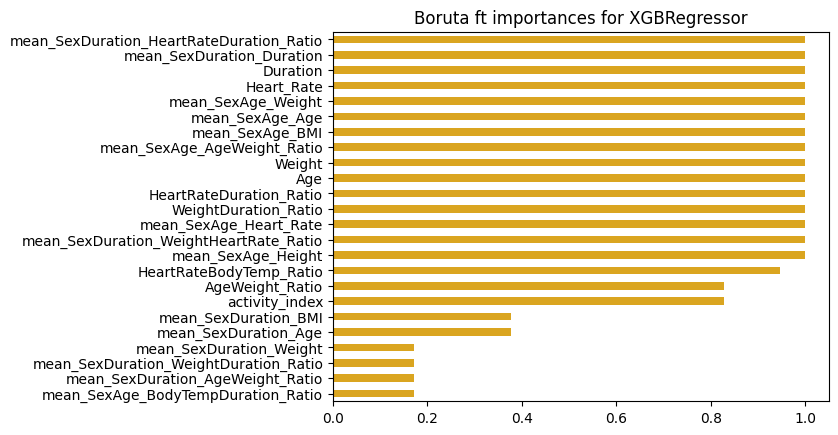

In [42]:
# calculate ft importances
importances = boruta(X, y, deepcopy(E), seed=10, plot=True, alpha=0.95, iterations=10)

__Features overview__

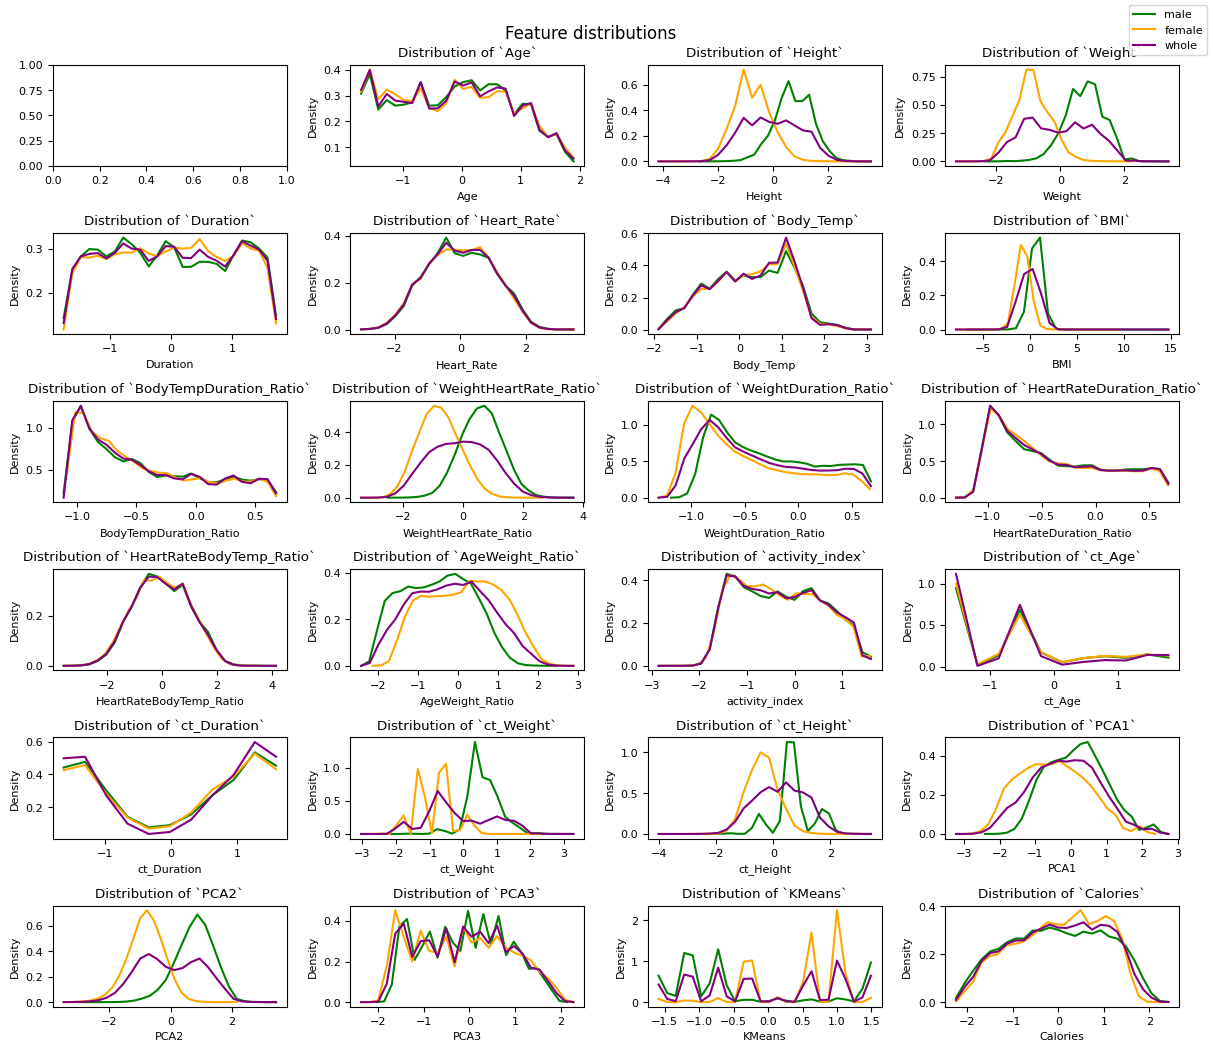

In [21]:
data = X.copy()
# scaler = pre.PowerTransformer()
# data[TARGET] = scaler.fit_transform(y.to_numpy().reshape(-1, 1))
data[TARGET] = y

COLUMNS = 4
ROWS = np.ceil(len(data.columns) / COLUMNS).astype(int)
SIZE = (COLUMNS * 3, ROWS * 1.75)
plt.rcParams.update({'font.size': 8})

fig, ax = plt.subplots(ROWS, COLUMNS, figsize=SIZE)
fig.suptitle('Feature distributions', fontsize=12)
fig.set_layout_engine('tight')

MALE = data.Sex > 0.5
for n, feature in enumerate(data.columns):
    row, col = n // COLUMNS, n % COLUMNS
    if feature == 'Sex':
        # feature_overview(ax[row][col], data[feature], FigureType.DENSITY, bins=25, color='purple')
        ...
    elif feature.startswith('ct_'):
        bins = data[feature].unique().size
        feature_overview(ax[row][col], data.loc[MALE, feature], FigureType.DENSITY, bins=bins, color='green')
        feature_overview(ax[row][col], data.loc[~MALE, feature], FigureType.DENSITY, bins=bins, color='orange')
        feature_overview(ax[row][col], data[feature], FigureType.DENSITY, bins=bins, color='purple')
    else:
        feature_overview(ax[row][col], data.loc[MALE, feature], FigureType.DENSITY, bins=25, color='green')
        feature_overview(ax[row][col], data.loc[~MALE, feature], FigureType.DENSITY, bins=25, color='orange')
        feature_overview(ax[row][col], data[feature], FigureType.DENSITY, bins=25, color='purple')

fig.legend(['male', 'female', 'whole'])
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7, 3.5))
# values = df.Weight / df.Height
# values = (df.Weight / df.Height) ** np.log(df.Heart_Rate / df.Duration)
values = np.log((df.Heart_Rate * df.Body_Temp * df.Duration * df.Age) ** (df.Weight / df.Height))
feature_overview(ax, values, FigureType.DENSITY)
plt.show()

__Correlations__

In [24]:
# THRESHOLD = 0.0

# data = X.copy()
# labels = data.columns
# data[TARGET] = y

# CORRELATIONS = ('pearson', 'spearman', 'kendall')
# # CORRELATIONS = ('pearson', )
# # drawing
# fig, axes = plt.subplots(len(CORRELATIONS), 1, figsize=(12, 4.5), sharex=True)
# fig.set_layout_engine('compressed')
# fig.suptitle('Correlations')
# for n, method in enumerate(CORRELATIONS):
#     ax = axes[n] if len(CORRELATIONS) > 1 else axes
#     ax.set_title(method.capitalize())
#     target_corr = data.corr(method)[[TARGET]].drop(TARGET).sort_values(TARGET, ascending=False)
#     values = target_corr.values.squeeze()
#     filtered = (abs(values) > THRESHOLD)
#     ax.imshow(values[filtered].reshape(1, -1), cmap='Blues')
#     ax.set_xticks(range(len(labels[filtered])), labels=labels[filtered], rotation=90)
#     ax.set_yticks([0], labels=[TARGET])
# plt.show()

__Final fit__

In [91]:
E = SGDRegressor(
    learning_rate='adaptive',
    eta0=0.01,
    # alpha=0.001,
    max_iter=15000,
    random_state=19,
)
_ = checkup(E, X, y, folds=3, scaler=y_pipe, clip=(1, np.inf))
sgd = model = E.fit(X, y)

Fold: 0; TRAIN RMSLE=0.05744; | VALID RMSLE=0.05837
Fold: 1; TRAIN RMSLE=0.05776; | VALID RMSLE=0.05768
Fold: 2; TRAIN RMSLE=0.05796; | VALID RMSLE=0.05715
MEAN: TRAIN RMSLE=0.05772; | VALID RMSLE=0.05773


In [93]:
E = XGBRegressor(  # see more https://xgboost.readthedocs.io/en/stable/parameter.html
    n_estimators=2500,
    learning_rate=0.2,
    max_depth=4,
    random_state=23,
    verbosity=0,
    device='cuda'
)
_ = checkup(E, X, y, folds=3, scaler=y_pipe, clip=(1, np.inf))
xgb = model = E.fit(X, y)

Fold: 0; TRAIN RMSLE=0.04512; | VALID RMSLE=0.05315
Fold: 1; TRAIN RMSLE=0.04509; | VALID RMSLE=0.05259
Fold: 2; TRAIN RMSLE=0.04522; | VALID RMSLE=0.05209
MEAN: TRAIN RMSLE=0.04514; | VALID RMSLE=0.05261


In [94]:
E = LGBMRegressor(  # see more https://lightgbm.readthedocs.io/en/latest/Parameters.html
    n_estimators=2500,
    learning_rate=0.2,
    max_depth=4,
    n_jobs=-1,
    random_state=23,
    verbose=-1,
    # device_type='cuda'
)
_ = checkup(E, X, y, folds=3, scaler=y_pipe, clip=(1, np.inf))
lgbm = model = E.fit(X, y)

Fold: 0; TRAIN RMSLE=0.04587; | VALID RMSLE=0.05330
Fold: 1; TRAIN RMSLE=0.04577; | VALID RMSLE=0.05263
Fold: 2; TRAIN RMSLE=0.04601; | VALID RMSLE=0.05219
MEAN: TRAIN RMSLE=0.04588; | VALID RMSLE=0.05270


In [42]:
E = CatBoostRegressor(  # see more https://catboost.ai/docs/en/concepts/loss-functions-regression
    n_estimators=2500,
    learning_rate=0.2,
    max_depth=4,
    random_state=23,
    silent=True,
    allow_writing_files=False,
    task_type='GPU'
)
_ = checkup(E, X, y, folds=3, scaler=y_pipe, clip=(1, np.inf))
catboost = model = E.fit(X, y)

Fold: 0; TRAIN RMSLE=0.05588; | VALID RMSLE=0.06002
Fold: 1; TRAIN RMSLE=0.05581; | VALID RMSLE=0.05943
Fold: 2; TRAIN RMSLE=0.05583; | VALID RMSLE=0.05947
MEAN: TRAIN RMSLE=0.05584; | VALID RMSLE=0.05964


In [ ]:
E = CatBoostRegressor(  # see more https://catboost.ai/docs/en/concepts/loss-functions-regression
    n_estimators=2500,
    learning_rate=0.2,
    max_depth=4,
    random_state=23,
    silent=True,
    allow_writing_files=False,
    # task_type='GPU'
)
_ = checkup(E, X, y, folds=3, scaler=y_pipe, clip=(1, np.inf))
catboost = model = E.fit(X, y)

__Submission__

In [ ]:
# SGD
T = pipe.transform(test.drop(columns=TARGET))
# values = sgd.predict(T)
values = np.clip(y_pipe.inverse_transform(sgd.predict(T).reshape(-1, 1))[:, 0], 1, None)

if (test[TARGET] != values).any():
    filecode = uuid.uuid4().hex
    test[TARGET] = values
    test.reset_index()[['id', TARGET]].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

c61aa90404414c9ba9bfa099c13b9951


In [ ]:
# XGB
T = pipe.transform(test.drop(columns=TARGET))
# values = xgb.predict(T)
values = np.clip(y_pipe.inverse_transform(xgb.predict(T).reshape(-1, 1))[:, 0], 1, None)

if (test[TARGET] != values).any():
    filecode = uuid.uuid4().hex
    test[TARGET] = values
    test.reset_index()[['id', TARGET]].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

f9f8f025ebf74b79a1ca33b9f0b0b074


In [ ]:
# LGBM
T = pipe.transform(test.drop(columns=TARGET))
# values = lgbm.predict(T)
values = np.clip(y_pipe.inverse_transform(lgbm.predict(T).reshape(-1, 1))[:, 0], 1, None)     # type: ignore

if (test[TARGET] != values).any():
    filecode = uuid.uuid4().hex
    test[TARGET] = values
    test.reset_index()[['id', TARGET]].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

524211eebf414beb89d0d25300c42a03


In [43]:
# CatBoost
T = pipe.transform(test.drop(columns=TARGET))
# values = catboost.predict(T)
values = np.clip(y_pipe.inverse_transform(catboost.predict(T).reshape(-1, 1))[:, 0], 1, None)

if (test[TARGET] != values).any():
    filecode = uuid.uuid4().hex
    test[TARGET] = values
    test.reset_index()[['id', TARGET]].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

643bbdb9f24344a49f926fdafd2a9e70


In [ ]:
#